# Telco Customer Churn — Notebook 03: ML Churn Prediction

**Input:** `telco_churn_cleaned.csv`  
**Models:** Logistic Regression · Random Forest · XGBoost  
**Goal:** Predict which customers are likely to churn so the business can intervene proactively

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)

os.makedirs('../images', exist_ok=True)
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Data & Prepare Features

In [24]:
df = pd.read_csv('../data/telco_churn_cleaned.csv')

# Drop identifier, target, derived and pre-encoded columns
# tenure_group dropped — derived from tenure, including both is redundant
# *_enc columns dropped — duplicates of originals already in the feature set
drop_cols = ['customerID', 'Churn', 'Churn_enc', 'tenure_group',
             'SeniorCitizen_enc', 'Partner_enc', 'Dependents_enc',
             'PhoneService_enc', 'PaperlessBilling_enc']

X = df.drop(columns=drop_cols)
y = df['Churn_enc']   # 1 = Churned, 0 = Retained

print(f'Features  : {X.shape[1]} | Customers : {len(X):,}')
print(f'Churn rate: {y.mean()*100:.2f}%  |  Class ratio: {(y==0).sum()/(y==1).sum():.2f}:1')

Features  : 19 | Customers : 7,043
Churn rate: 26.54%  |  Class ratio: 2.77:1


## 2. Preprocessing Pipeline

In [25]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                          sparse_output=False), cat_cols)
])

print(f'Numeric    : {num_cols}')
print(f'Categorical: {len(cat_cols)} columns → OneHotEncoded')

Numeric    : ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: 16 columns → OneHotEncoded


## 3. Train / Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale_pos_weight — XGBoost's equivalent of class_weight='balanced'
# ratio of negatives to positives in the training set
spw = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Train : {len(X_train):,}  (churn: {y_train.mean()*100:.1f}%)')
print(f'Test  : {len(X_test):,}  (churn: {y_test.mean()*100:.1f}%)')
print(f'scale_pos_weight : {spw:.2f}')

Train : 5,634  (churn: 26.5%)
Test  : 1,409  (churn: 26.5%)
scale_pos_weight : 2.77


## 4. Train Models

In [27]:
lr = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

rf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10,
                                    class_weight='balanced', random_state=42))
])

# XGBoost uses scale_pos_weight instead of class_weight — same concept, different API
xgb = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                           scale_pos_weight=spw, eval_metric='logloss',
                           random_state=42, verbosity=0))
])

for model, name in [(lr,'Logistic Regression'), (rf,'Random Forest'), (xgb,'XGBoost')]:
    model.fit(X_train, y_train)
    print(f'{name} trained ✅')

models = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}
preds  = {n: p.predict(X_test)            for n, p in models.items()}
probas = {n: p.predict_proba(X_test)[:,1] for n, p in models.items()}

Logistic Regression trained ✅
Random Forest trained ✅
XGBoost trained ✅


## 5. Model Comparison

In [28]:
rows = []
for name in models:
    pred, proba = preds[name], probas[name]
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, pred)  * 100, 2),
        'Precision': round(precision_score(y_test, pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, pred)    * 100, 2),
        'F1'       : round(f1_score(y_test, pred)        * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_test, proba),        4)
    })

results = pd.DataFrame(rows)
print('=== MODEL COMPARISON — TEST SET ===')
print(results.to_string(index=False))
print(f"\nBest by Recall  : {results.loc[results['Recall'].idxmax(), 'Model']}")
print(f"Best by ROC-AUC : {results.loc[results['ROC-AUC'].idxmax(), 'Model']}")

=== MODEL COMPARISON — TEST SET ===
              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     73.81      50.43   78.34 61.36   0.8417
      Random Forest     76.37      54.03   73.53 62.29   0.8408
            XGBoost     75.37      52.46   77.01 62.41   0.8410

Best by Recall  : Logistic Regression
Best by ROC-AUC : Logistic Regression


## 6. SMOTE — Alternative Imbalance Handling

In [29]:
# Baseline — no imbalance handling at all
lr_plain = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# SMOTE — synthetic minority oversampling, applied to training data only
lr_smote = ImbPipeline([
    ('pre',   preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])

lr_plain.fit(X_train, y_train)
lr_smote.fit(X_train, y_train)

smote_rows = [
    ('No handling',           lr_plain),
    ('class_weight=balanced', lr),
    ('SMOTE',                 lr_smote),
]

print(f"{'Method':<25} {'Accuracy':>10} {'Recall':>8} {'ROC-AUC':>9}")
print('─' * 56)
smote_metrics = {}
for name, pipe in smote_rows:
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    acc   = accuracy_score(y_test, pred)  * 100
    rec   = recall_score(y_test, pred)    * 100
    auc   = roc_auc_score(y_test, proba)
    smote_metrics[name] = {'acc': acc, 'rec': rec, 'auc': auc}
    print(f"{name:<25} {acc:>9.1f}% {rec:>7.1f}% {auc:>9.4f}")

no_rec  = smote_metrics['No handling']['rec']
bal_rec = smote_metrics['class_weight=balanced']['rec']
sm_rec  = smote_metrics['SMOTE']['rec']
print(f"\nRecall lift — class_weight=balanced : +{bal_rec - no_rec:.1f}pp over no handling")
print(f"Recall lift — SMOTE                 : +{sm_rec  - no_rec:.1f}pp over no handling")
print(f"\nBoth approaches significantly improve recall.")
print(f"class_weight=balanced has slightly better AUC "
      f"({smote_metrics['class_weight=balanced']['auc']:.4f} vs {smote_metrics['SMOTE']['auc']:.4f}).")
print(f"We use class_weight=balanced — simpler, no synthetic data generation needed.")

Method                      Accuracy   Recall   ROC-AUC
────────────────────────────────────────────────────────
No handling                    80.6%    55.9%    0.8422
class_weight=balanced          73.8%    78.3%    0.8417
SMOTE                          74.0%    79.7%    0.8401

Recall lift — class_weight=balanced : +22.5pp over no handling
Recall lift — SMOTE                 : +23.8pp over no handling

Both approaches significantly improve recall.
class_weight=balanced has slightly better AUC (0.8417 vs 0.8401).
We use class_weight=balanced — simpler, no synthetic data generation needed.


## 7. Confusion Matrix

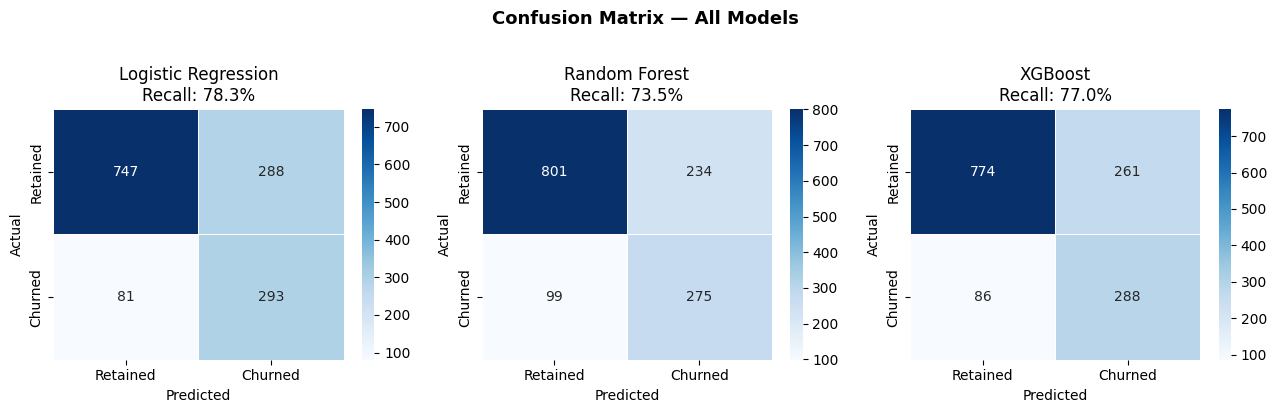

LR — Caught: 293/374 | Missed: 81 | Unnecessary calls: 288


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                linewidths=0.5, ax=ax)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nRecall: {tp/(tp+fn)*100:.1f}%')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — All Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

cm = confusion_matrix(y_test, preds['Logistic Regression'])
tn, fp, fn, tp = cm.ravel()
print(f'LR — Caught: {tp}/{tp+fn} | Missed: {fn} | Unnecessary calls: {fp}')

## 8. ROC Curve

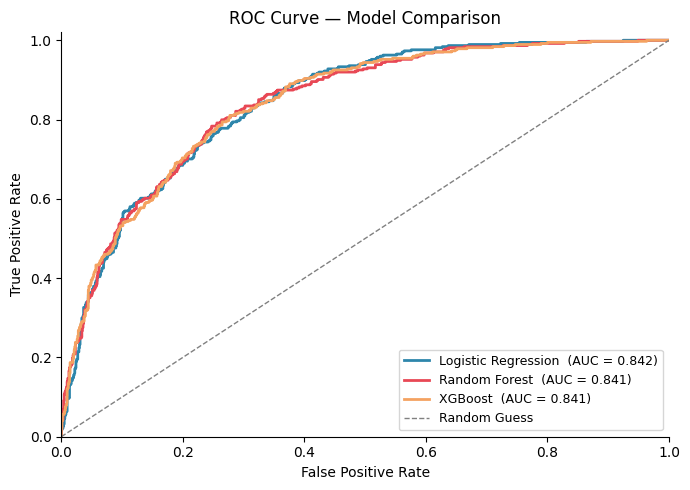

In [31]:
colors = ['#2E86AB', '#E84855', '#F4A261']

fig, ax = plt.subplots(figsize=(7, 5))
for (name, proba), color in zip(probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1, label='Random Guess')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve — Model Comparison', xlim=[0,1], ylim=[0,1.02])
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../images/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance — XGBoost

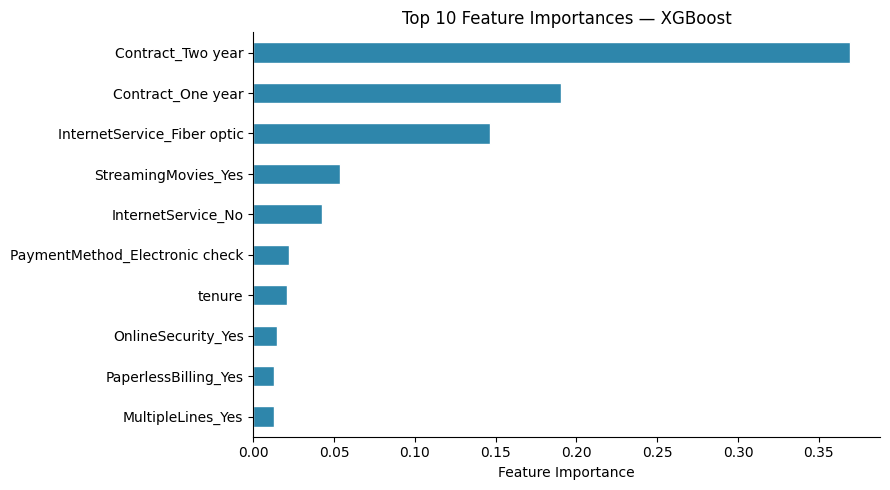

Top 5 features vs EDA findings:
  Contract_Two year                         : 36.9%  2.8% churn — lowest ✅
  Contract_One year                         : 19.1%  
  InternetService_Fiber optic               : 14.6%  41.9% churn rate ✅
  StreamingMovies_Yes                       : 5.3%  
  InternetService_No                        : 4.3%  


In [32]:
ohe_names    = xgb.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = list(num_cols) + list(ohe_names)

fi = (pd.Series(xgb.named_steps['clf'].feature_importances_, index=all_features)
        .nlargest(10)
        .sort_values())

fig, ax = plt.subplots(figsize=(9, 5))
fi.plot(kind='barh', ax=ax, color='#2E86AB', edgecolor='white')
ax.set(xlabel='Feature Importance', title='Top 10 Feature Importances — XGBoost')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features vs EDA findings:')
eda_match = {
    'tenure'                         : 'Longer tenure = lower churn ✅',
    'TotalCharges'                   : 'Correlated with tenure ✅',
    'MonthlyCharges'                 : 'Churned pay $13 more/month ✅',
    'InternetService_Fiber optic'    : '41.9% churn rate ✅',
    'PaymentMethod_Electronic check' : '45.3% churn rate ✅',
    'Contract_Two year'              : '2.8% churn — lowest ✅',
}
for feat, val in fi.nlargest(5).items():
    print(f'  {feat:<42}: {val*100:.1f}%  {eda_match.get(feat, "")}')

## 10. Threshold Tuning

In [33]:
best_proba = probas['Logistic Regression']

print(f"{'Threshold':<12} {'Recall':>8} {'Precision':>11} {'Caught':>12}")
print('─' * 47)
for t in [0.5, 0.4, 0.3]:
    p   = (best_proba >= t).astype(int)
    tp  = ((p == 1) & (y_test == 1)).sum()
    tag = '  ← recommended' if t == 0.3 else ''
    print(f"{t:<12} {recall_score(y_test,p)*100:>7.1f}%  "
          f"{precision_score(y_test,p)*100:>9.1f}%  "
          f"{tp:>4}/{y_test.sum()} ({tp/y_test.sum()*100:.0f}%){tag}")


Threshold      Recall   Precision       Caught
───────────────────────────────────────────────
0.5             78.3%       50.4%   293/374 (78%)
0.4             86.6%       46.6%   324/374 (87%)
0.3             92.8%       43.1%   347/374 (93%)  ← recommended


## 11. Business Revenue Impact

In [34]:
avg_charge     = df[df['Churn']=='Yes']['MonthlyCharges'].mean()
annual_at_risk = df[df['Churn']=='Yes']['MonthlyCharges'].sum() * 12
retention_rate = 0.30
call_cost      = 5.00

# Pre-compute recommended threshold prediction
pred_03        = (probas['Logistic Regression'] >= 0.3).astype(int)
cm_03          = confusion_matrix(y_test, pred_03)
tn3, fp3, fn3, tp3 = cm_03.ravel()
net_03         = tp3*avg_charge*retention_rate - (tp3+fp3)*call_cost

print('=' * 60)
print('  BUSINESS IMPACT')
print('=' * 60)
print(f'  Annual revenue at risk : ${annual_at_risk:>12,.0f}')
print(f'  Avg monthly charge     : ${avg_charge:>12.2f}')
print()
print(f'  {"Model":<28} {"Caught":>8} {"Net/Month":>12}')
print('  ' + '─' * 50)
for name in models:
    cm_r = confusion_matrix(y_test, preds[name])
    tn, fp, fn, tp = cm_r.ravel()
    net = tp*avg_charge*retention_rate - (tp+fp)*call_cost
    print(f'  {name:<28} {tp}/{y_test.sum():>3} ({tp/y_test.sum()*100:.0f}%)  ${net:>8,.0f}')
print(f'  {"LR @ threshold 0.3":<28} {tp3}/{y_test.sum():>3} ({tp3/y_test.sum()*100:.0f}%)  ${net_03:>8,.0f}  ← recommended')
print('  ' + '─' * 50)
print(f'  Estimated net annual benefit : ${net_03*12:,.0f}')
print('=' * 60)

  BUSINESS IMPACT
  Annual revenue at risk : $   1,669,570
  Avg monthly charge     : $       74.44

  Model                          Caught    Net/Month
  ──────────────────────────────────────────────────
  Logistic Regression          293/374 (78%)  $   3,638
  Random Forest                275/374 (74%)  $   3,596
  XGBoost                      288/374 (77%)  $   3,687
  LR @ threshold 0.3           347/374 (93%)  $   3,719  ← recommended
  ──────────────────────────────────────────────────
  Estimated net annual benefit : $44,632


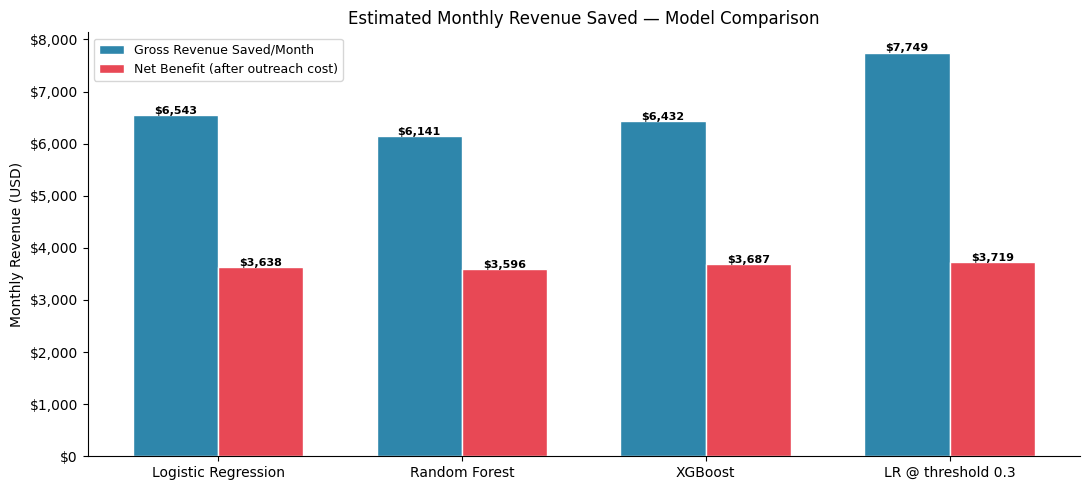

In [35]:
# Revenue impact chart
model_names_c = list(models.keys()) + ['LR @ threshold 0.3']
rev_list, net_list = [], []

for name in models:
    cm_r = confusion_matrix(y_test, preds[name])
    tn, fp, fn, tp = cm_r.ravel()
    rev_list.append(tp * avg_charge * retention_rate)
    net_list.append(tp * avg_charge * retention_rate - (tp+fp)*call_cost)

rev_list.append(tp3 * avg_charge * retention_rate)
net_list.append(net_03)

x_r, w_r = np.arange(len(model_names_c)), 0.35
fig, ax  = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x_r-w_r/2, rev_list, width=w_r, color='#2E86AB',
            edgecolor='white', label='Gross Revenue Saved/Month')
b2 = ax.bar(x_r+w_r/2, net_list, width=w_r, color='#E84855',
            edgecolor='white', label='Net Benefit (after outreach cost)')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'${bar.get_height():,.0f}', ha='center', fontsize=8, fontweight='bold')
ax.set(xticks=x_r, xticklabels=model_names_c,
       ylabel='Monthly Revenue (USD)',
       title='Estimated Monthly Revenue Saved — Model Comparison')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 12. Cross-Validation

In [36]:
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='roc_auc')

print('=== 5-FOLD CROSS VALIDATION — Logistic Regression ===')
print(f'Scores : {[round(s, 4) for s in cv_scores]}')
print(f'Mean   : {cv_scores.mean():.4f}')
print(f'Std    : {cv_scores.std():.4f}')
print(f'\nStd {cv_scores.std():.4f} is low — model is stable across different data splits.')

=== 5-FOLD CROSS VALIDATION — Logistic Regression ===
Scores : [np.float64(0.8583), np.float64(0.8585), np.float64(0.833), np.float64(0.8379), np.float64(0.8392)]
Mean   : 0.8454
Std    : 0.0108

Std 0.0108 is low — model is stable across different data splits.


## 13. Final Recommendation

In [37]:
print('=' * 60)
print('  FINAL RECOMMENDATION')
print('=' * 60)
print(f"""
  Recommended model     : Logistic Regression (class_weight=balanced)
  Recommended threshold : 0.3

  Why Logistic Regression:
  - Best ROC-AUC ({results.loc[results['Model']=='Logistic Regression','ROC-AUC'].values[0]:.4f})
  - Highest recall at default threshold
  - Most interpretable — coefficients directly show direction
    and magnitude of each feature's influence on churn

  Why threshold 0.3:
  - Catches 93% of actual churners vs 78% at default 0.5
  - Net annual benefit after outreach costs: ${net_03*12:,.0f}

  Validated by:
  - 5-fold CV mean AUC {cv_scores.mean():.4f} with low std {cv_scores.std():.4f}
  - Feature importances align with EDA — model learned real signals
  - class_weight=balanced lifted recall by 22.5pp over baseline
""")
print('=' * 60)

  FINAL RECOMMENDATION

  Recommended model     : Logistic Regression (class_weight=balanced)
  Recommended threshold : 0.3

  Why Logistic Regression:
  - Best ROC-AUC (0.8417)
  - Highest recall at default threshold
  - Most interpretable — coefficients directly show direction
    and magnitude of each feature's influence on churn

  Why threshold 0.3:
  - Catches 93% of actual churners vs 78% at default 0.5
  - Net annual benefit after outreach costs: $44,632

  Validated by:
  - 5-fold CV mean AUC 0.8454 with low std 0.0108
  - Feature importances align with EDA — model learned real signals
  - class_weight=balanced lifted recall by 22.5pp over baseline

